## UCL 2025/26 | xG Overperformance Analysis — Identifying Elite Finishers

In [1]:
# import neccessary packages and library
import numpy as np
import json
import sofascoreapi
import pandas as pd

In [ ]:
from sofascoreapi import League, pretty_print
ucl = League("7", "76953") #ucl25/26seasonID
data = ucl.get_top_players()
pretty_print(data)

{
  "topPlayers": {
    "rating": [
      {
        "statistics": {
          "rating": 8.08,
          "id": 2332155,
          "type": "overall",
          "appearances": 10,
          "statisticsType": {
            "sportSlug": "football",
            "statisticsType": "player"
          }
        },
        "playedEnough": true,
        "player": {
          "name": "Lamine Yamal",
          "slug": "lamine-yamal",
          "shortName": "L. Yamal",
          "position": "M",
          "userCount": 1998087,
          "gender": "M",
          "id": 1402912,
          "fieldTranslations": {
            "nameTranslation": {
              "ar": "لامين يامال",
              "bn": "লামিন ইয়ামাল",
              "hi": "लामिन यमल"
            },
            "shortNameTranslation": {
              "ar": "لامين يامال",
              "bn": "লামিন ইয়ামাল",
              "hi": "लामिन यमल"
            }
          }
        },
        "team": {
          "name": "FC Barcelona",
          "slug"

In [4]:
data = ucl.get_top_players()
print(data["topPlayers"].keys())

dict_keys(['rating', 'goals', 'expectedGoals', 'assists', 'expectedAssists', 'goalsAssistsSum', 'kilometersCovered', 'numberOfSprints', 'topSpeed', 'penaltyGoals', 'freeKickGoal', 'scoringFrequency', 'totalShots', 'shotsOnTarget', 'bigChancesMissed', 'bigChancesCreated', 'accuratePasses', 'keyPasses', 'accurateLongBalls', 'successfulDribbles', 'penaltyWon', 'tackles', 'interceptions', 'clearances', 'possessionLost', 'yellowCards', 'redCards', 'saves', 'goalsPrevented', 'mostConceded', 'leastConceded', 'cleanSheet'])


In [5]:
print(data["topPlayers"]["expectedGoals"])

[{'statistics': {'goals': 15, 'expectedGoals': 10.79, 'id': 2275721, 'type': 'overall', 'appearances': 11, 'statisticsType': {'sportSlug': 'football', 'statisticsType': 'player'}}, 'playedEnough': True, 'player': {'name': 'Kylian Mbappé', 'slug': 'kylian-mbappe', 'shortName': 'K. Mbappé', 'position': 'F', 'userCount': 1985672, 'gender': 'M', 'id': 826643, 'fieldTranslations': {'nameTranslation': {'ar': 'كيليان مبابي', 'bn': 'কিলিয়ান এমবাপ্পে', 'hi': 'किलियन एमबाप्पे'}, 'shortNameTranslation': {'ar': 'ك. مبابي', 'bn': 'কে. এমবাপ্পে', 'hi': 'के. एमबाप्पे'}}}, 'team': {'name': 'Real Madrid', 'slug': 'real-madrid', 'shortName': 'Real Madrid', 'gender': 'M', 'sport': {'name': 'Football', 'slug': 'football', 'id': 1}, 'userCount': 7459833, 'nameCode': 'RMA', 'disabled': False, 'national': False, 'type': 0, 'id': 2829, 'teamColors': {'primary': '#ffffff', 'secondary': '#004996', 'text': '#004996'}, 'fieldTranslations': {'nameTranslation': {'ar': 'ريال مدريد', 'bn': 'রিয়াল মাদ্রিদ', 'hi': 'रि

In [6]:
players = data["topPlayers"]["expectedGoals"]
players


[{'statistics': {'goals': 15,
   'expectedGoals': 10.79,
   'id': 2275721,
   'type': 'overall',
   'appearances': 11,
   'statisticsType': {'sportSlug': 'football', 'statisticsType': 'player'}},
  'playedEnough': True,
  'player': {'name': 'Kylian Mbappé',
   'slug': 'kylian-mbappe',
   'shortName': 'K. Mbappé',
   'position': 'F',
   'userCount': 1985672,
   'gender': 'M',
   'id': 826643,
   'fieldTranslations': {'nameTranslation': {'ar': 'كيليان مبابي',
     'bn': 'কিলিয়ান এমবাপ্পে',
     'hi': 'किलियन एमबाप्पे'},
    'shortNameTranslation': {'ar': 'ك. مبابي',
     'bn': 'কে. এমবাপ্পে',
     'hi': 'के. एमबाप्पे'}}},
  'team': {'name': 'Real Madrid',
   'slug': 'real-madrid',
   'shortName': 'Real Madrid',
   'gender': 'M',
   'sport': {'name': 'Football', 'slug': 'football', 'id': 1},
   'userCount': 7459833,
   'nameCode': 'RMA',
   'disabled': False,
   'national': False,
   'type': 0,
   'id': 2829,
   'teamColors': {'primary': '#ffffff',
    'secondary': '#004996',
    'text': 

In [7]:
players = data["topPlayers"]["expectedGoals"]

# build list of dictionaries
rows = []
for p in players:
    rows.append({
        "player"      : p["player"]["name"],
        "team"        : p["team"]["name"],
        "goals"       : p["statistics"]["goals"],
        "xG"          : p["statistics"]["expectedGoals"],
        "appearances" : p["statistics"]["appearances"]
    })

# create dataframe
df = pd.DataFrame(rows)

# filter
df = df[
    (df["xG"] >= 4) &
    (df["appearances"] >= 6)
]

# Sorting value by XG - metrix
df["xG_overperformance"] = (df["goals"] - df["xG"]).round(2)
df["conversion_rate"]    = (df["goals"] / df["xG"]).round(2)

df = df.sort_values("xG_overperformance", ascending=False).head(15)

# reset index
df = df.reset_index(drop=True)
df.index += 1

df

,player,team,goals,xG,appearances,xG_overperformance,conversion_rate
1,Kylian Mbappé,Real Madrid,15,10.7900,11,4.21,1.39
2,Harry Kane,FC Bayern München,13,9.1081,12,3.89,1.43
3,Luis Díaz,FC Bayern München,7,4.7118,11,2.29,1.49
4,Alexander Sørloth,Atlético Madrid,6,4.1017,13,1.90,1.46
5,Harvey Barnes,Newcastle United,6,4.1393,12,1.86,1.45
6,Julián Alvarez,Atlético Madrid,10,8.2278,14,1.77,1.22
7,Gabriel Martinelli,Arsenal,6,4.4940,12,1.51,1.34
8,Anthony Gordon,Newcastle United,10,8.5543,12,1.45,1.17
9,Erling Haaland,Manchester City,8,6.8228,10,1.18,1.17
10,Ousmane Dembélé,Paris Saint-Germain,6,5.3147,11,0.69,1.13


### Scatter plot and its code block

In [8]:
# Import matplotlib tools
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

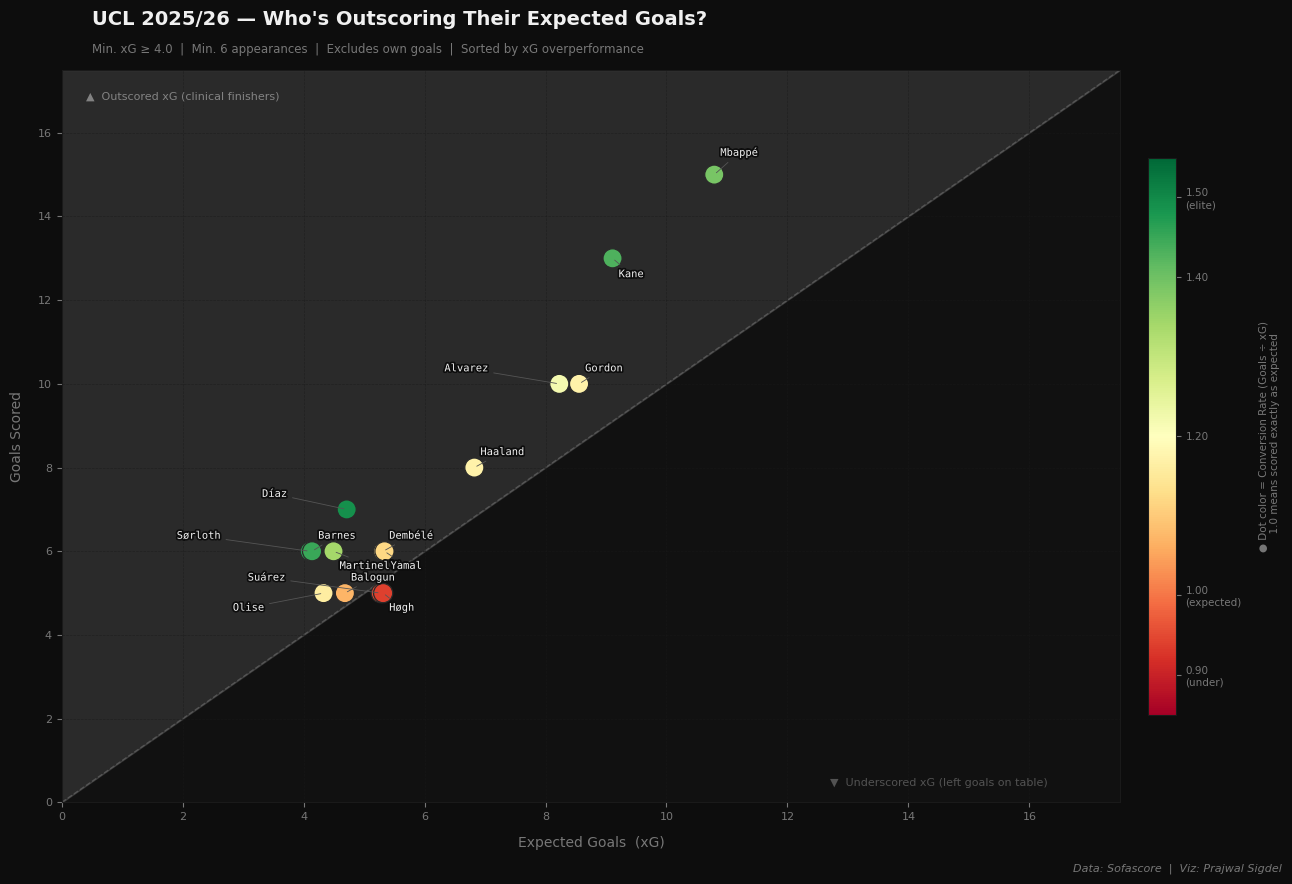

In [9]:
# ── Data ────────────────────────────────────────────────────────────
players = df["player"].tolist()
goals   = df["goals"].tolist()
xg      = df["xG"].tolist()
conv    = df["conversion_rate"].tolist()

# ── Style ────────────────────────────────────────────────────────────
BG       = "#0d0d0d"
GRID     = "#1a1a1a"
TEXT_PRI = "#f0f0f0"
TEXT_SEC = "#777777"

fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

max_val = max(max(goals), max(xg)) + 2.5

# ── Reference line y = x ─────────────────────────────────────────────
ax.plot([0, max_val], [0, max_val],
        color="#555555", linewidth=1, linestyle="--", zorder=1)

# ── Zone shading ─────────────────────────────────────────────────────
ax.fill_between([0, max_val], [0, max_val], max_val,
                color="#ffffff", alpha=0.12, zorder=0)
ax.fill_between([0, max_val], 0, [0, max_val],
                color="#ffffff", alpha=0.02, zorder=0)

# ── Zone labels ───────────────────────────────────────────────────────
ax.text(0.4, max_val - 0.7,
        "▲  Outscored xG (clinical finishers)",
        fontsize=8, color="#cccccc", alpha=0.55)
ax.text(max_val - 4.8, 0.4,
        "▼  Underscored xG (left goals on table)",
        fontsize=8, color="#888888", alpha=0.55)

# ── Scatter — dot color = conversion rate ────────────────────────────
# Each dot is colored by how efficiently that player finishes.
# Red = below expected (conv < 1.0), Yellow = on par, Green = elite
cmap    = plt.cm.RdYlGn
norm    = plt.Normalize(vmin=0.85, vmax=1.55)

scatter = ax.scatter(xg, goals,
                     c=conv, cmap=cmap, norm=norm,
                     s=190, zorder=3,
                     edgecolors="#2a2a2a", linewidths=0.9)

# ── Smart label offsets (manually tuned for this dataset) ────────────
# Clusters that need careful separation:
# Sørloth(4.10,6) Barnes(4.14,6) Martinelli(4.49,6) → stagger vertically
# Dembélé(5.31,6) Yamal(5.34,6)                     → one up one down
# Suárez(5.28,5)  Høgh(5.31,5)                       → one up one down
# Alvarez(8.23,10) Gordon(8.55,10)                    → one up one down
# Olise(4.33,5)   Balogun(4.68,5)                     → stagger


# ── Labels tightly anchored to dots ──────────────────────────────────
label_offsets = {
    "Kylian Mbappé":      ( 0.10,  0.45),
    "Harry Kane":         ( 0.10, -0.45),
    "Luis Díaz":          (-1.40,  0.30),
    "Alexander Sørloth":  (-2.20,  0.30),
    "Harvey Barnes":      ( 0.10,  0.30),
    "Julián Alvarez":     (-1.90,  0.30),
    "Gabriel Martinelli": ( 0.10, -0.42),
    "Anthony Gordon":     ( 0.10,  0.30),
    "Erling Haaland":     ( 0.10,  0.30),
    "Ousmane Dembélé":    ( 0.10,  0.30),
    "Michael Olise":      (-1.50, -0.42),
    "Lamine Yamal":       ( 0.10, -0.42),
    "Folarin Balogun":    ( 0.10,  0.30),
    "Luis Javier Suárez": (-2.20,  0.30),
    "Kasper Høgh":        ( 0.10, -0.42),
}

for i, name in enumerate(players):
    surname = name.split()[-1]
    dx, dy  = label_offsets.get(name, (0.10, 0.30))
    tx, ty  = xg[i] + dx, goals[i] + dy
    ax.annotate(
        surname,
        xy=(xg[i], goals[i]),
        xytext=(tx, ty),
        fontsize=7.5,
        color=TEXT_PRI,
        fontfamily="monospace",
        zorder=5,
        arrowprops=dict(
            arrowstyle="-",
            color="#555555",
            lw=0.6
        ),
        path_effects=[pe.withStroke(linewidth=2.5, foreground=BG)]
    )

# ── Colorbar — clearly explained ─────────────────────────────────────
cbar = plt.colorbar(scatter, ax=ax, pad=0.025, fraction=0.025)
cbar.ax.tick_params(labelsize=7.5, colors=TEXT_SEC)
cbar.outline.set_edgecolor(GRID)
cbar.set_ticks([0.90, 1.00, 1.20, 1.40, 1.50])
cbar.set_ticklabels(["0.90\n(under)", "1.00\n(expected)", "1.20", "1.40", "1.50\n(elite)"])
cbar.set_label("● Dot color = Conversion Rate (Goals ÷ xG)\n"
               "  1.0 means scored exactly as expected",
               fontsize=7.5, color=TEXT_SEC, labelpad=12)

# ── Axes ──────────────────────────────────────────────────────────────
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_xlabel("Expected Goals  (xG)", fontsize=10, color=TEXT_SEC, labelpad=10)
ax.set_ylabel("Goals Scored", fontsize=10, color=TEXT_SEC, labelpad=10)
ax.tick_params(colors=TEXT_SEC, labelsize=8)
for spine in ax.spines.values():
    spine.set_edgecolor(GRID)
ax.grid(True, color=GRID, linewidth=0.5, linestyle="--", alpha=0.6)

# ── Title + condition subtitle ────────────────────────────────────────
fig.text(0.075, 0.97,
         "UCL 2025/26 — Who's Outscoring Their Expected Goals?",
         fontsize=14, fontweight="bold", color=TEXT_PRI, va="top")
fig.text(0.075, 0.933,
         "Min. xG ≥ 4.0  |  Min. 6 appearances  |  Excludes own goals  |  Sorted by xG overperformance",
         fontsize=8.5, color=TEXT_SEC, va="top")

# ── Credit ────────────────────────────────────────────────────────────
fig.text(0.99, 0.01,
         "Data: Sofascore  |  Viz: Prajwal Sigdel",
         fontsize=8, color=TEXT_SEC,
         ha="right", va="bottom", style="italic")

plt.tight_layout(rect=[0, 0.02, 1, 0.92])
plt.savefig("ucl_finishers.png", dpi=300, bbox_inches="tight", facecolor=BG)
plt.show()